### TRACÉ DU DIAGRAMME DE PHASES

1) SANS SEUIL


Colonnes disponibles : ['epsilon', 'fhn_eps', 'cr', 'graph_uuid', 'COH', 'OSC', 'FMSD']


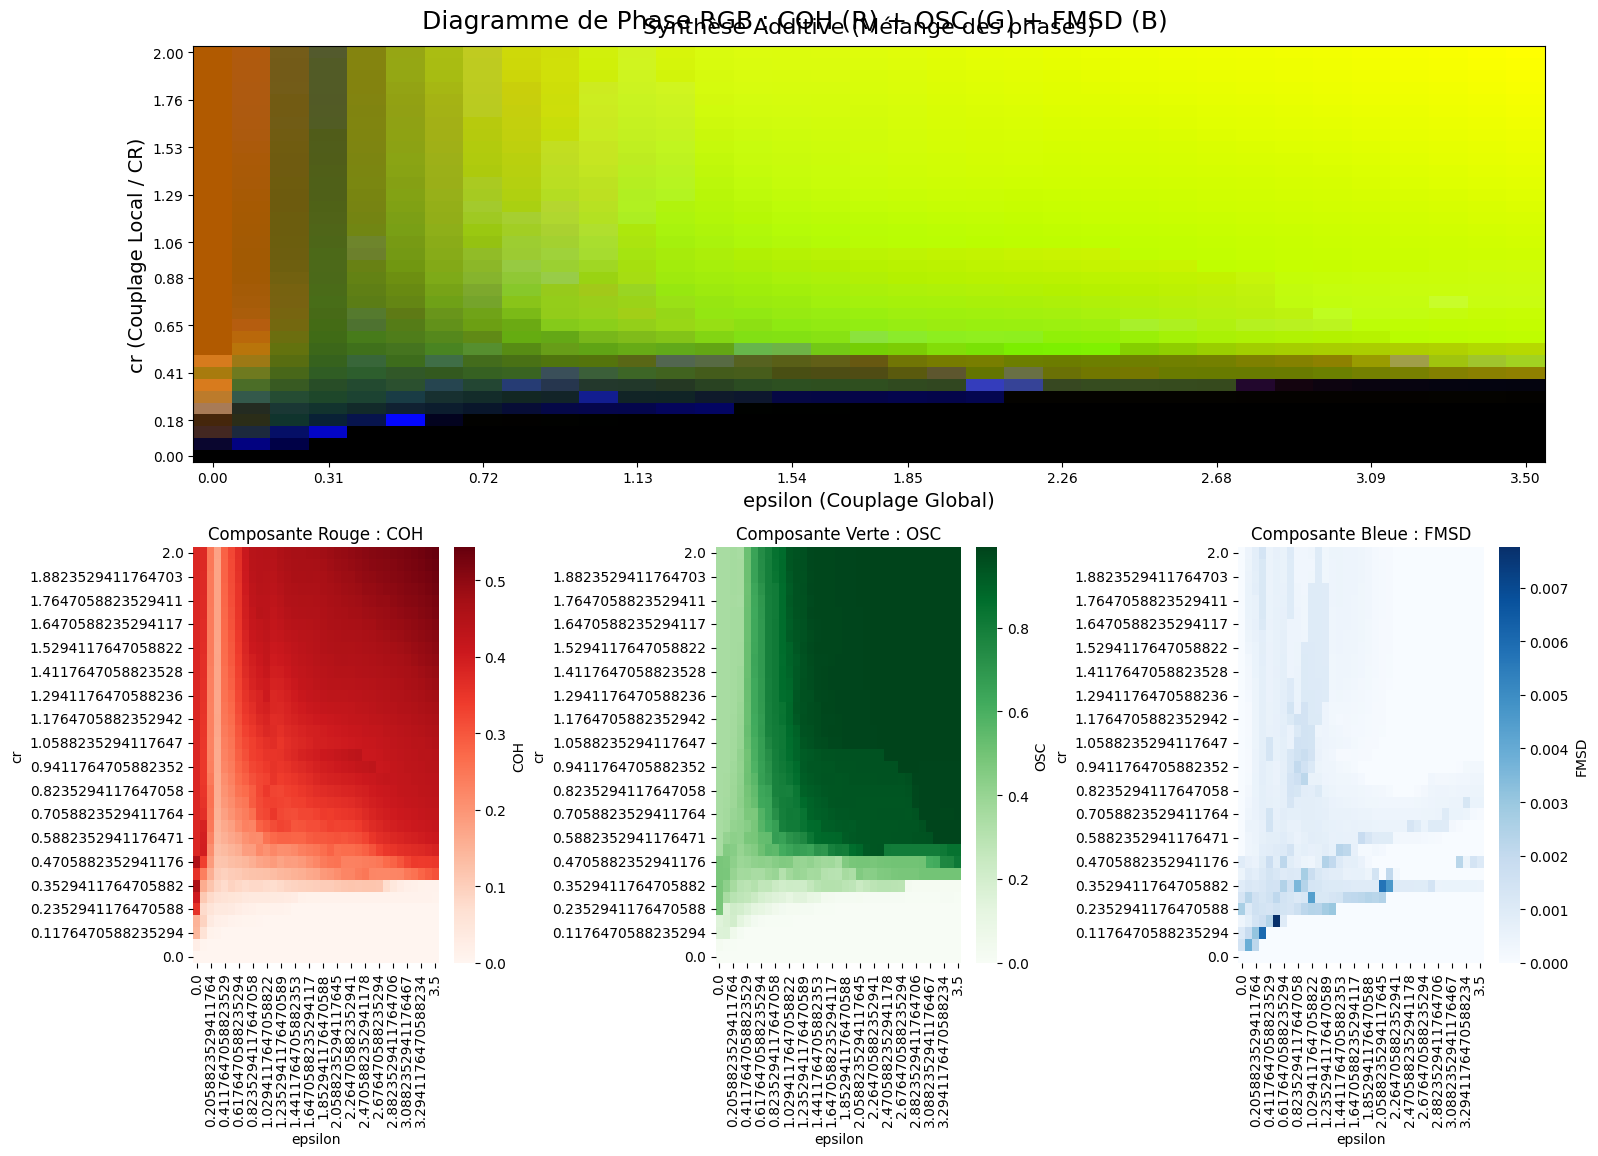

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. CHARGEMENT ET CONFIGURATION
# ==========================================

# Chemin vers ton fichier (MODIFIE LE SI BESOIN)
file_path = '/Users/constantindeumier/Desktop/Dev_Numerical_project/pass/results_Phase_Diagram.csv'

# Chargement
df = pd.read_csv(file_path)

print("Colonnes disponibles :", df.columns.tolist())

# --- CONFIGURATION DES AXES (Tes deux couplages) ---
# D'après tes logs précédents, c'est probablement epsilon et cr.
# Vérifie si c'est 'fhn_eps' ou 'cr' qui varie avec 'epsilon'.
x_col = 'epsilon'  # Axe X
y_col = 'cr'       # Axe Y

# --- CONFIGURATION DES COULEURS (Tes 3 paramètres d'ordre) ---
# Assigne chaque mesure à une couleur primaire.
# Change les noms ci-dessous pour correspondre exactement à tes colonnes CSV.
red_metric   = 'COH'   # Rouge : Cohérence (Synchronisation de phase)
green_metric = 'OSC'   # Vert  : Oscillation (Amplitude moyenne ou firing rate)
blue_metric  = 'FMSD'  # Bleu  : Complexité (ou autre métrique dynamique)

# ==========================================
# 2. PRÉPARATION DES MATRICES (CORRIGÉ)
# ==========================================

# OPTION PROPRE : On sélectionne uniquement les colonnes qu'on veut moyenner
cols_to_average = [red_metric, green_metric, blue_metric]

# On groupe par X et Y, et on ne garde que les métriques
pivot_df = df.groupby([y_col, x_col])[cols_to_average].mean().reset_index()

# Note : Si tu as une erreur ici, assure-toi que x_col et y_col sont bien écrits
# comme dans ton CSV ('epsilon' et 'cr' d'après ton message).

# Fonction helper pour créer une matrice 2D à partir du tableau
def create_matrix(data, value_col, x_col, y_col):
    # pivot peut renvoyer des NaNs si la grille n'est pas régulière, on remplit avec 0
    return data.pivot(index=y_col, columns=x_col, values=value_col).fillna(0)

# Création des 3 matrices brutes
M_red   = create_matrix(pivot_df, red_metric, x_col, y_col)
M_green = create_matrix(pivot_df, green_metric, x_col, y_col)
M_blue  = create_matrix(pivot_df, blue_metric, x_col, y_col)

# Récupération des labels pour les axes
x_labels = M_red.columns.values
y_labels = M_red.index.values

# Conversion en numpy arrays pour le traitement d'image
R = M_red.values
G = M_green.values
B = M_blue.values


# ==========================================
# 3. NORMALISATION (0 à 1)
# ==========================================
# Pour que la couleur marche, il faut que min=0 (noir) et max=1 (couleur pleine)
# On normalise chaque canal indépendamment.

def normalize(arr):
    # Évite la division par zéro si tout est constant
    if np.max(arr) - np.min(arr) == 0:
        return np.zeros_like(arr) if np.max(arr) == 0 else np.ones_like(arr)
    return (arr - np.min(arr)) / (np.max(arr) - np.min(arr))

R_norm = normalize(R)
G_norm = normalize(G)
B_norm = normalize(B)

# Création de l'image RGB finale (stacking des 3 matrices)
RGB_img = np.dstack((R_norm, G_norm, B_norm))

# ==========================================
# 4. VISUALISATION
# ==========================================

fig = plt.figure(figsize=(16, 12))
plt.suptitle(f"Diagramme de Phase RGB : {red_metric} (R) + {green_metric} (G) + {blue_metric} (B)", fontsize=18, y=0.96)

# --- PLOT 1 : La synthèse additive (L'image principale) ---
ax_main = plt.subplot2grid((2, 3), (0, 0), colspan=3)
im = ax_main.imshow(RGB_img, origin='lower', aspect='auto')

# Labels des axes (on en met juste quelques-uns pour pas surcharger)
ax_main.set_xlabel(f"{x_col} (Couplage Global)", fontsize=14)
ax_main.set_ylabel(f"{y_col} (Couplage Local / CR)", fontsize=14)

# Bricolage pour afficher les tiques correctement
x_ticks_loc = np.linspace(0, len(x_labels)-1, 10, dtype=int)
y_ticks_loc = np.linspace(0, len(y_labels)-1, 10, dtype=int)
ax_main.set_xticks(x_ticks_loc)
ax_main.set_xticklabels([f"{x_labels[i]:.2f}" for i in x_ticks_loc])
ax_main.set_yticks(y_ticks_loc)
ax_main.set_yticklabels([f"{y_labels[i]:.2f}" for i in y_ticks_loc])

ax_main.set_title("Synthèse Additive (Mélange des phases)", fontsize=16, pad=10)

# --- PLOT 2, 3, 4 : Les canaux individuels (La légende) ---
# Rouge
ax_R = plt.subplot2grid((2, 3), (1, 0))
sns.heatmap(M_red, ax=ax_R, cmap="Reds", cbar_kws={'label': red_metric})
ax_R.set_title(f"Composante Rouge : {red_metric}")
ax_R.invert_yaxis() # Seaborn met le 0 en haut par défaut, on inverse pour matcher imshow

# Vert
ax_G = plt.subplot2grid((2, 3), (1, 1))
sns.heatmap(M_green, ax=ax_G, cmap="Greens", cbar_kws={'label': green_metric})
ax_G.set_title(f"Composante Verte : {green_metric}")
ax_G.invert_yaxis()

# Bleu
ax_B = plt.subplot2grid((2, 3), (1, 2))
sns.heatmap(M_blue, ax=ax_B, cmap="Blues", cbar_kws={'label': blue_metric})
ax_B.set_title(f"Composante Bleue : {blue_metric}")
ax_B.invert_yaxis()

plt.tight_layout()
plt.show()


2) AVEC SEUIL

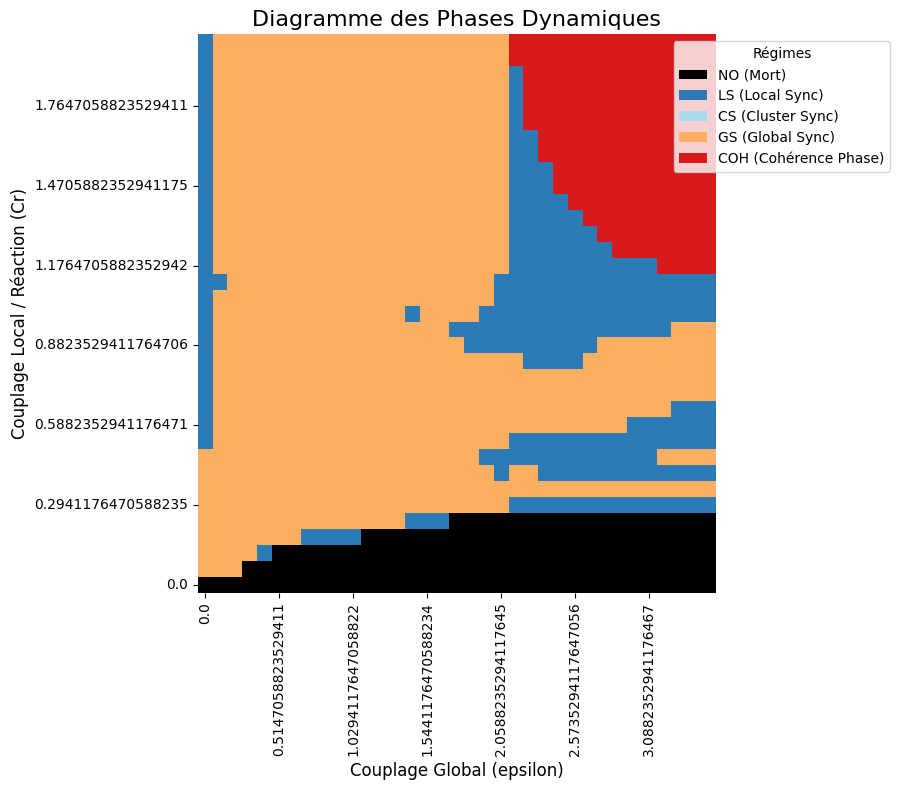

Répartition des régimes trouvés :
regime
NO (Mort)            139
LS (Local Sync)      218
CS (Cluster Sync)    704
GS (Global Sync)     164
Name: count, dtype: int64


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns

# ==========================================
# 1. CHARGEMENT ET NETTOYAGE
# ==========================================

df = pd.read_csv(file_path)

# Variables (Mets ici les noms exacts de tes colonnes)
x_col = 'epsilon'
y_col = 'cr'
col_coh = 'COH'
col_osc = 'OSC'
col_fmsd = 'FMSD'

# Aggrégation propre (pour éviter le bug de texte précédent)
# On groupe par les hyperparamètres et on moyenne les métriques
df_agg = df.groupby([y_col, x_col])[[col_osc, col_coh, col_fmsd]].mean().reset_index()

# ==========================================
# 2. DEFINITION DES PHASES (LOGIQUE PAPIER)
# ==========================================

def classify_regime(row):
    osc = row[col_osc]
    coh = row[col_coh]
    fmsd = row[col_fmsd]
    
    # Ordre de priorité des filtres (Hierarchie) :
    
    # 1. NO (No Oscillation) : Si c'est mort, c'est mort.
    if osc < 0.001:
        return 0 # Code pour NO
    
    # 2. COH (Phase Coherence) : Le stade ultime de l'ordre.
    if coh > 0.995:
        return 4 # Code pour COH
        
    # 3. GS (Global Synchronization) : Tout le monde oscille (osc > 0.99).
    # Note : Le papier distingue GS et CS. Si FMSD est bas, c'est GS.
    if osc > 0.99:
        # Dans le papier, GS est défini strictement par l'amplitude.
        # Mais si le FMSD est élevé, c'est techniquement du CS.
        # On va respecter la priorité stricte du papier ou insérer une nuance.
        # Ici : Priorité à GS si l'amplitude est massive.
        return 3 # Code pour GS
        
    # 4. CS (Cluster Synchronization) : La dispersion des fréquences est élevée.
    if fmsd > 0.0001:
        return 2 # Code pour CS
        
    # 5. LS (Local Synchronization) : Le reste (activté faible, faible dispersion).
    return 1 # Code pour LS

# Appliquer la classification
df_agg['regime'] = df_agg.apply(classify_regime, axis=1)

# Création de la matrice pivot pour l'affichage
phase_matrix = df_agg.pivot(index=y_col, columns=x_col, values='regime').fillna(0)
# On s'assure que l'axe Y est dans le bon sens (matplotlib vs matrice)
phase_matrix = phase_matrix.sort_index(ascending=True) 

# ==========================================
# 3. VISUALISATION
# ==========================================

# Définition des couleurs et labels
# 0: NO (Noir), 1: LS (Bleu), 2: CS (Vert), 3: GS (Orange), 4: COH (Rouge)
colors = ['#000000', '#2c7bb6', '#abd9e9', '#fdae61', '#d7191c']
regime_labels = ['NO (Mort)', 'LS (Local Sync)', 'CS (Cluster Sync)', 'GS (Global Sync)', 'COH (Cohérence Phase)']
cmap = mcolors.ListedColormap(colors)

fig, ax = plt.subplots(figsize=(10, 8))

# Affichage de la Heatmap discrète
# On utilise pcolormesh ou imshow. Seaborn heatmap est pratique ici.
sns.heatmap(phase_matrix, 
            cmap=cmap, 
            ax=ax, 
            cbar=False, # On fait notre propre légende custom
            xticklabels=5, yticklabels=5) # Alléger les ticks

ax.invert_yaxis() # Important pour avoir l'origine en bas

ax.set_title("Diagramme des Phases Dynamiques", fontsize=16)
ax.set_xlabel("Couplage Global (epsilon)", fontsize=12)
ax.set_ylabel("Couplage Local / Réaction (Cr)", fontsize=12)

# --- Création d'une légende sur mesure ---
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=colors[0], label=regime_labels[0]),
    Patch(facecolor=colors[1], label=regime_labels[1]),
    Patch(facecolor=colors[2], label=regime_labels[2]),
    Patch(facecolor=colors[3], label=regime_labels[3]),
    Patch(facecolor=colors[4], label=regime_labels[4])
]

ax.legend(handles=legend_elements, loc='upper right', title="Régimes", bbox_to_anchor=(1.35, 1))

plt.tight_layout()
plt.show()

# --- Statistique rapide pour vérifier ---
print("Répartition des régimes trouvés :")
print(df_agg['regime'].value_counts().sort_index().rename(index=dict(enumerate(regime_labels))))


<>:36: SyntaxWarning: invalid escape sequence '\e'
<>:36: SyntaxWarning: invalid escape sequence '\e'
/var/folders/d9/yr1d00yj0w58yxqtc2zv6q580000gp/T/ipykernel_46599/785448622.py:36: SyntaxWarning: invalid escape sequence '\e'
  xlabel = "Couplage Global ($\epsilon$)"


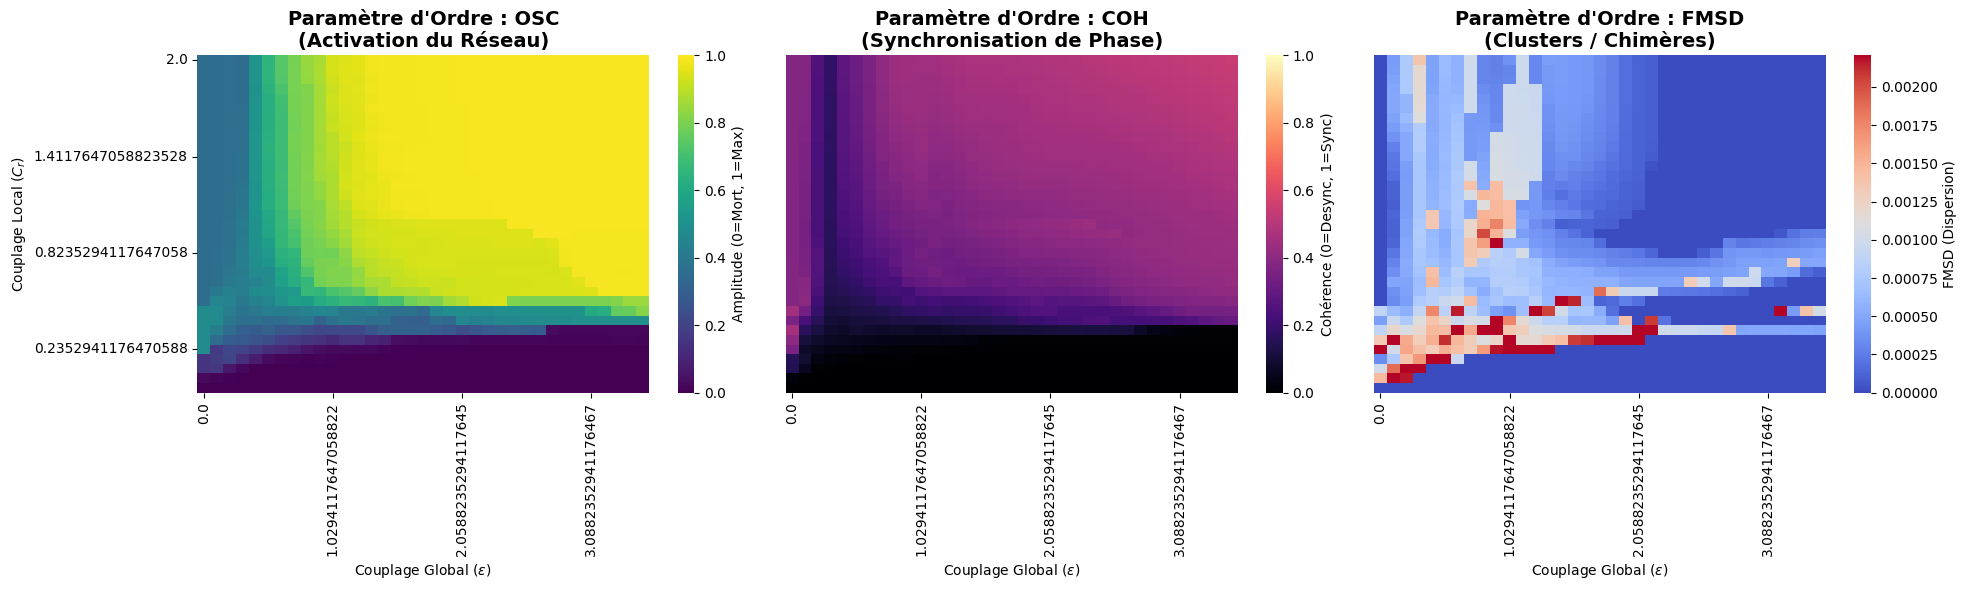

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. PRÉPARATION DES DONNÉES
# ==========================================

# Remplacer par ton fichier de résultats
# file_path = "Data_output/chemins_vers_tes_resultats.csv"
# df = pd.read_csv(file_path)

# Variables
x_col = 'epsilon'  # Couplage global
y_col = 'cr'       # Couplage local ou réactif
col_osc = 'OSC'    # Amplitude globale
col_coh = 'COH'    # Cohérence de phase
col_fmsd = 'FMSD'  # Dispersion des fréquences

# Aggrégation (Moyenne sur les seeds/itérations)
df_agg = df.groupby([y_col, x_col])[[col_osc, col_coh, col_fmsd]].mean().reset_index()

# Création des matrices pivots
pivot_osc = df_agg.pivot(index=y_col, columns=x_col, values=col_osc).sort_index(ascending=False)
pivot_coh = df_agg.pivot(index=y_col, columns=x_col, values=col_coh).sort_index(ascending=False)
pivot_fmsd = df_agg.pivot(index=y_col, columns=x_col, values=col_fmsd).sort_index(ascending=False)

# ==========================================
# 2. VISUALISATION CÔTE À CÔTE
# ==========================================

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# --- Paramètres communs pour le style ---
xlabel = "Couplage Global ($\epsilon$)"
ylabel = "Couplage Local ($C_r$)"
tick_step = 10 # Affiche 1 tick sur 10 pour ne pas surcharger les axes

# --- 1. OSC (Activité Globale) ---
sns.heatmap(pivot_osc, ax=axes[0], cmap="viridis", vmin=0, vmax=1,
            xticklabels=tick_step, yticklabels=tick_step, cbar_kws={'label': 'Amplitude (0=Mort, 1=Max)'})
axes[0].set_title("Paramètre d'Ordre : OSC\n(Activation du Réseau)", fontsize=14, fontweight='bold')
axes[0].set_xlabel(xlabel)
axes[0].set_ylabel(ylabel)

# --- 2. COH (Cohérence de Phase) ---
# Utilise 'plasma' ou 'inferno' pour bien contraster avec OSC
sns.heatmap(pivot_coh, ax=axes[1], cmap="magma", vmin=0, vmax=1,
            xticklabels=tick_step, yticklabels=tick_step, cbar_kws={'label': 'Cohérence (0=Desync, 1=Sync)'})
axes[1].set_title("Paramètre d'Ordre : COH\n(Synchronisation de Phase)", fontsize=14, fontweight='bold')
axes[1].set_xlabel(xlabel)
axes[1].set_ylabel("") # On enlève le label Y pour alléger au milieu
axes[1].set_yticks([]) # Optionnel : enlever les ticks Y si c'est aligné

# --- 3. FMSD (Dispersion Fréquentielle) ---
# 'coolwarm' est bien pour voir les déviations. 
# Attention : FMSD n'est pas borné entre 0 et 1 comme les autres, 
# souvent c'est très petit. On laisse l'échelle automatique ou on utilise robust=True.
sns.heatmap(pivot_fmsd, ax=axes[2], cmap="coolwarm", robust=True,
            xticklabels=tick_step, yticklabels=tick_step, cbar_kws={'label': 'FMSD (Dispersion)'})
axes[2].set_title("Paramètre d'Ordre : FMSD\n(Clusters / Chimères)", fontsize=14, fontweight='bold')
axes[2].set_xlabel(xlabel)
axes[2].set_ylabel("")
axes[2].set_yticks([])

plt.tight_layout()
plt.show()


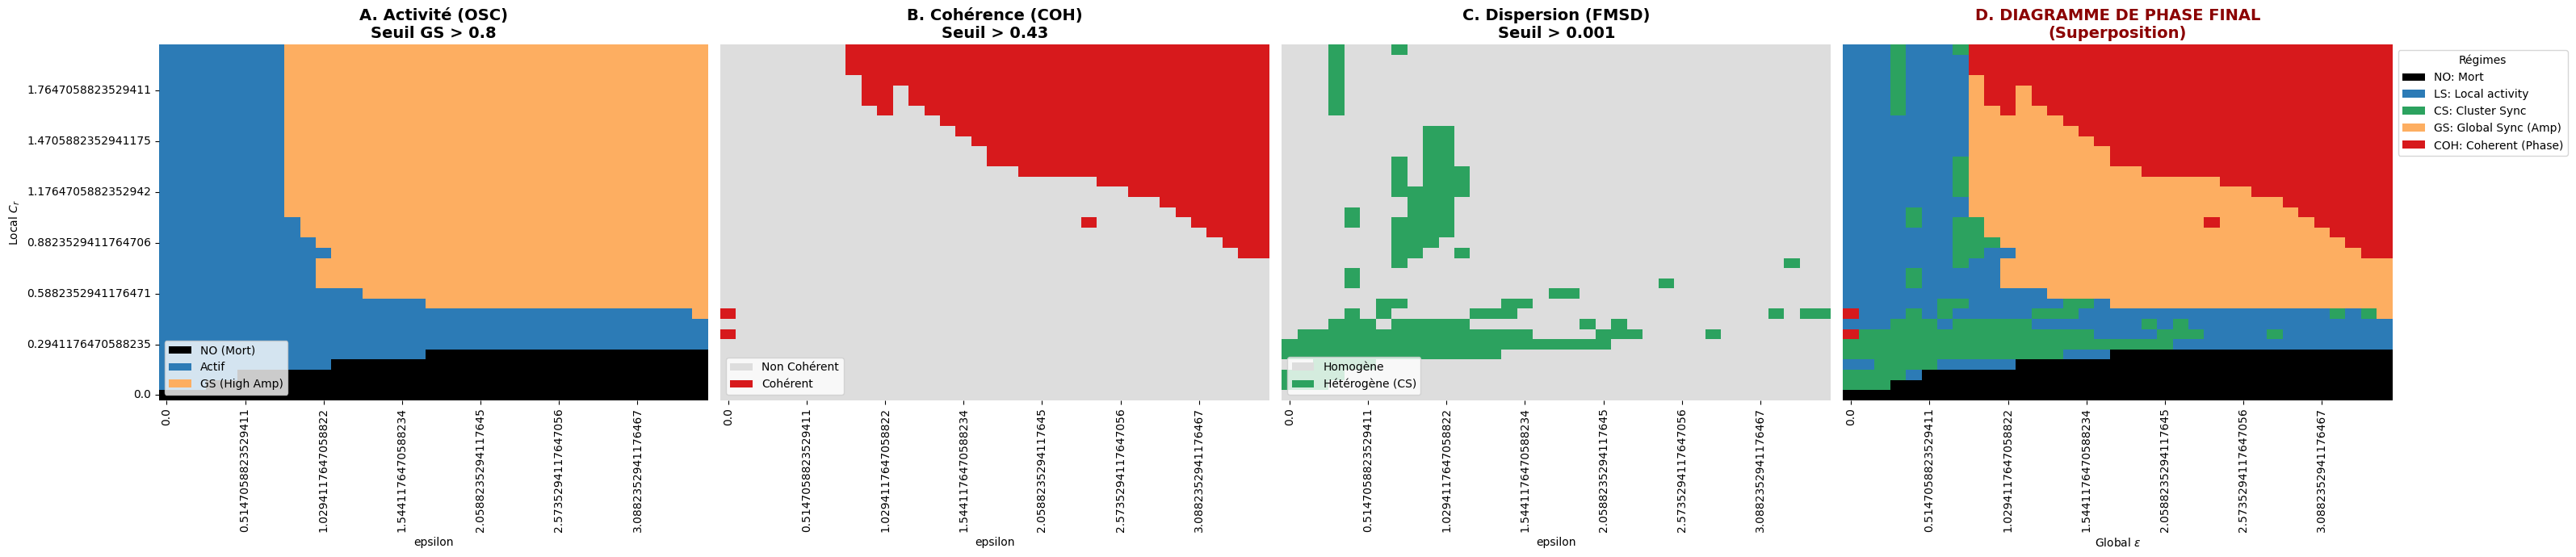

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

# ==========================================
# 1. PRÉPARATION
# ==========================================
# (Supposons que df est chargé)
# df = pd.read_csv(file_path)

x_col = 'epsilon'
y_col = 'cr'
col_osc = 'OSC'
col_coh = 'COH'
col_fmsd = 'FMSD'

# Seuils définis dans ton message précédent
THRESH_DEAD = 0.001
THRESH_GS_AMP = 0.8
THRESH_COH = 0.43
THRESH_CS_FMSD = 0.001

# Aggrégation
df_agg = df.groupby([y_col, x_col])[[col_osc, col_coh, col_fmsd]].mean().reset_index()

# Matrices pivots brutes
p_osc = df_agg.pivot(index=y_col, columns=x_col, values=col_osc).sort_index(ascending=True)
p_coh = df_agg.pivot(index=y_col, columns=x_col, values=col_coh).sort_index(ascending=True)
p_fmsd = df_agg.pivot(index=y_col, columns=x_col, values=col_fmsd).sort_index(ascending=True)

# ==========================================
# 2. DISCRÉTISATION (COMPOSANTS)
# ==========================================

# A. OSC Activity Check
osc_discrete = p_osc.copy()
osc_discrete[:] = 1               # Activité standard
osc_discrete[p_osc < THRESH_DEAD] = 0   # Mort
osc_discrete[p_osc > THRESH_GS_AMP] = 2 # GS (Amplitude forte)

# B. COH Check
coh_discrete = (p_coh > THRESH_COH).astype(int)

# C. FMSD Check
fmsd_discrete = (p_fmsd > THRESH_CS_FMSD).astype(int)


# ==========================================
# 3. RECONSTRUCTION DU DIAGRAMME FINAL (SUPERPOSITION)
# ==========================================

def get_final_regime(row):
    # Logique de priorité (Hierarchy of Phases)
    osc = row[col_osc]
    coh = row[col_coh]
    fmsd = row[col_fmsd]
    
    # 1. Le système est-il mort ?
    if osc < THRESH_DEAD:
        return 0 # NO (Noir)
    
    # 2. Le système est-il parfaitement cohérent ? (Le "Saint Graal")
    if coh > THRESH_COH:
        return 4 # COH (Rouge)
        
    # 3. Le système a-t-il une amplitude massive ?
    if osc > THRESH_GS_AMP:
        return 3 # GS (Orange)
        
    # 4. Le système est-il désynchronisé en clusters/chimères ?
    if fmsd > THRESH_CS_FMSD:
        return 2 # CS (Vert)
        
    # 5. Sinon, c'est de la synchro locale standard
    return 1 # LS (Bleu)

# Application à la dataframe agrégée
df_agg['final_regime'] = df_agg.apply(get_final_regime, axis=1)
p_final = df_agg.pivot(index=y_col, columns=x_col, values='final_regime').sort_index(ascending=True)


# ==========================================
# 4. VISUALISATION (1x4)
# ==========================================

fig, axes = plt.subplots(1, 4, figsize=(32, 7))
tick_freq = 5

# --- PLOT 1 : ACTIVITÉ (OSC) ---
cmap_osc = ListedColormap(['#000000', '#2c7bb6', '#fdae61']) # Noir, Bleu, Orange
sns.heatmap(osc_discrete, ax=axes[0], cmap=cmap_osc, cbar=False, xticklabels=tick_freq, yticklabels=tick_freq)
axes[0].set_title(f"A. Activité (OSC)\nSeuil GS > {THRESH_GS_AMP}", fontsize=14, fontweight='bold')
axes[0].invert_yaxis()
axes[0].set_ylabel(r"Local $C_r$")
# Légende 1
leg1 = [Patch(facecolor='#000000', label='NO (Mort)'), Patch(facecolor='#2c7bb6', label='Actif'), Patch(facecolor='#fdae61', label='GS (High Amp)')]
axes[0].legend(handles=leg1, loc='lower left')


# --- PLOT 2 : COHÉRENCE (COH) ---
cmap_coh = ListedColormap(['#dddddd', '#d7191c']) # Gris, Rouge
sns.heatmap(coh_discrete, ax=axes[1], cmap=cmap_coh, cbar=False, xticklabels=tick_freq, yticklabels=tick_freq)
axes[1].set_title(f"B. Cohérence (COH)\nSeuil > {THRESH_COH}", fontsize=14, fontweight='bold')
axes[1].invert_yaxis()
axes[1].set_yticks([]) # Enlever ticks Y
axes[1].set_ylabel("")
# Légende 2
leg2 = [Patch(facecolor='#dddddd', label='Non Cohérent'), Patch(facecolor='#d7191c', label='Cohérent')]
axes[1].legend(handles=leg2, loc='lower left')


# --- PLOT 3 : DISPERSION (FMSD) ---
cmap_fmsd = ListedColormap(['#dddddd', '#2ca25f']) # Gris, Vert
sns.heatmap(fmsd_discrete, ax=axes[2], cmap=cmap_fmsd, cbar=False, xticklabels=tick_freq, yticklabels=tick_freq)
axes[2].set_title(f"C. Dispersion (FMSD)\nSeuil > {THRESH_CS_FMSD}", fontsize=14, fontweight='bold')
axes[2].invert_yaxis()
axes[2].set_yticks([])
axes[2].set_ylabel("")
# Légende 3
leg3 = [Patch(facecolor='#dddddd', label='Homogène'), Patch(facecolor='#2ca25f', label='Hétérogène (CS)')]
axes[2].legend(handles=leg3, loc='lower left')


# --- PLOT 4 : SYNTHÈSE (SUPERPOSITION) ---
# 0:NO(Noir), 1:LS(Bleu), 2:CS(Vert), 3:GS(Orange), 4:COH(Rouge)
colors_final = ['#000000', '#2c7bb6', '#2ca25f', '#fdae61', '#d7191c']
cmap_final = ListedColormap(colors_final)
sns.heatmap(p_final, ax=axes[3], cmap=cmap_final, cbar=False, xticklabels=tick_freq, yticklabels=tick_freq)
axes[3].set_title("D. DIAGRAMME DE PHASE FINAL\n(Superposition)", fontsize=14, fontweight='bold', color='darkred')
axes[3].invert_yaxis()
axes[3].set_yticks([])
axes[3].set_ylabel("")
axes[3].set_xlabel(r"Global $\epsilon$")

# Légende 4 (Complète)
leg4 = [
    Patch(facecolor=colors_final[0], label='NO: Mort'),
    Patch(facecolor=colors_final[1], label='LS: Local activity'),
    Patch(facecolor=colors_final[2], label='CS: Cluster Sync'),
    Patch(facecolor=colors_final[3], label='GS: Global Sync (Amp)'),
    Patch(facecolor=colors_final[4], label='COH: Coherent (Phase)')
]
axes[3].legend(handles=leg4, loc='upper left', bbox_to_anchor=(1, 1), title="Régimes")

plt.tight_layout()
plt.show()
